In [1]:
import scanpy as sc
import os
from scib_metrics.benchmark import Benchmarker, BioConservation, BatchCorrection
import pandas as pd

/usr/local/lib/python3.12/dist-packages/optuna/study/_optimize.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from optuna import progress_bar as pbar_module


In [2]:
data_dir = "./data/Neftel_ss2/"
dataset = data_dir.split('/')[-2].lower()

In [ ]:
CancerGPT = sc.read_h5ad(data_dir + "CancerGPT_github_" + dataset + ".h5ad")
medium = sc.read_h5ad(data_dir + "CancerGPT_medium_" + dataset + ".h5ad")
pcpt_nomvc = sc.read_h5ad(data_dir + "CancerGPT_pcpt_nomvc_" + dataset + ".h5ad")
pcpt_mvc = sc.read_h5ad(data_dir + "CancerGPT_pcpt_mvc_" + dataset + ".h5ad")
both_nomvc = sc.read_h5ad(data_dir + "CancerGPT_both_nomvc_" + dataset + ".h5ad")
both_mvc = sc.read_h5ad(data_dir + "CancerGPT_both_mvc_" + dataset + ".h5ad")
nocond_nobalance = sc.read_h5ad(data_dir + "CancerGPT_nocond_nobalance_" + dataset + ".h5ad")
nocond_withbalance = sc.read_h5ad(data_dir + "CancerGPT_nocond_withbalance_" + dataset + ".h5ad")
withcond_nobalance = sc.read_h5ad(data_dir + "CancerGPT_withcond_nobalance_" + dataset + ".h5ad")
withcond_withbalance = sc.read_h5ad(data_dir + "CancerGPT_withcond_withbalance_" + dataset + ".h5ad")
withcond_withbalance_nozero = sc.read_h5ad(data_dir + "CancerGPT_withcond_withbalance_nozero_" + dataset + ".h5ad")

adata = CancerGPT
adata.obsm["medium"] = medium.obsm["CancerGPT"]
adata.obsm["pcpt_nomvc"] = pcpt_nomvc.obsm["CancerGPT"]
adata.obsm["pcpt_mvc"] = pcpt_mvc.obsm["CancerGPT"]
adata.obsm["both_nomvc"] = both_nomvc.obsm["CancerGPT"]
adata.obsm["both_mvc"] = both_mvc.obsm["CancerGPT"]
adata.obsm["nocond_nobalance"] = nocond_nobalance.obsm["CancerGPT"]
adata.obsm["nocond_withbalance"] = nocond_withbalance.obsm["CancerGPT"]
adata.obsm["withcond_nobalance"] = withcond_nobalance.obsm["CancerGPT"]
adata.obsm["withcond_withbalance"] = withcond_withbalance.obsm["CancerGPT"]
adata.obsm["withcond_withbalance_nozero"] = withcond_withbalance_nozero.obsm["CancerGPT"]

del(adata.obsm["CancerGPT"])

all_keys = list(adata.obsm.keys())

In [4]:
CancerGPT = sc.read_h5ad(data_dir + "CancerGPT_github_" + dataset + ".h5ad")
bigger = sc.read_h5ad(data_dir + "CancerGPT_bigger_" + dataset + ".h5ad")
medium = sc.read_h5ad(data_dir + "CancerGPT_medium_" + dataset + ".h5ad")
pcpt = sc.read_h5ad(data_dir + "CancerGPT_pcpt_" + dataset + ".h5ad")
hid4x = sc.read_h5ad(data_dir + "CancerGPT_hid4x_" + dataset + ".h5ad")
fewerheads = sc.read_h5ad(data_dir + "CancerGPT_fewerheads_" + dataset + ".h5ad")
gelu_prenorm = sc.read_h5ad(data_dir + "CancerGPT_gelu_prenorm_" + dataset + ".h5ad")
pcpt_bs128 = sc.read_h5ad(data_dir + "CancerGPT_pcpt_bs128_" + dataset + ".h5ad")
bigger_6heads = sc.read_h5ad(data_dir + "CancerGPT_bigger_6heads_" + dataset + ".h5ad")
condtech_early = sc.read_h5ad(data_dir + "CancerGPT_condtech_early_" + dataset + ".h5ad")
condtech_done = sc.read_h5ad(data_dir + "CancerGPT_condtech_done_" + dataset + ".h5ad")
condtech_coarse = sc.read_h5ad(data_dir + "CancerGPT_condtech_coarse_" + dataset + ".h5ad")
coarse = sc.read_h5ad(data_dir + "CancerGPT_coarse_" + dataset + ".h5ad")
brain = sc.read_h5ad(data_dir + "CancerGPT_brain_" + dataset + ".h5ad")
big = sc.read_h5ad(data_dir + "CancerGPT_big_" + dataset + ".h5ad")
pcpt_lobs = sc.read_h5ad(data_dir + "CancerGPT_pcpt_lobs_" + dataset + ".h5ad")
scGPT = sc.read_h5ad(data_dir + "scGPT_" + dataset + "_2999_sample.h5ad")
scFoundation = sc.read_h5ad(data_dir + "scFoundation_" + dataset + "_2999_sample.h5ad")

adata = CancerGPT
adata.obsm["github"] = CancerGPT.obsm["CancerGPT"]
adata.obsm["bigger"] = bigger.obsm["CancerGPT"]
adata.obsm["medium"] = medium.obsm["CancerGPT"]
adata.obsm["pcpt"] = pcpt.obsm["CancerGPT"]
adata.obsm["hid4x"] = hid4x.obsm["CancerGPT"]
adata.obsm["fewerheads"] = fewerheads.obsm["CancerGPT"]
adata.obsm["gelu_prenorm"] = gelu_prenorm.obsm["CancerGPT"]
adata.obsm["pcpt_bs128"] = pcpt_bs128.obsm["CancerGPT"]
adata.obsm["bigger_6heads"] = bigger_6heads.obsm["CancerGPT"]
adata.obsm["condtech_early"] = condtech_early.obsm["CancerGPT"]
adata.obsm["condtech_done"] = condtech_done.obsm["CancerGPT"]
adata.obsm["condtech_coarse"] = condtech_coarse.obsm["CancerGPT"]
adata.obsm["coarse"] = coarse.obsm["CancerGPT"]
adata.obsm["brain"] = brain.obsm["CancerGPT"]
adata.obsm["big"] = big.obsm["CancerGPT"]
adata.obsm["pcpt_lobs"] = pcpt_lobs.obsm["CancerGPT"]
adata.obsm["scGPT"] = scGPT.obsm["X_scGPT"]
adata.obsm["scFoundation"] = scFoundation.obsm["scfoundation_embedding"]

del(adata.obsm["CancerGPT"])

all_keys = list(adata.obsm.keys())

In [23]:
CancerGPT = sc.read_h5ad(data_dir + "CancerGPT_github_" + dataset + ".h5ad")
medium = sc.read_h5ad(data_dir + "CancerGPT_medium_" + dataset + ".h5ad")
pcpt_hilr = sc.read_h5ad(data_dir + "CancerGPT_pcpt_hilr_" + dataset + ".h5ad")
pcpt_lobs = sc.read_h5ad(data_dir + "CancerGPT_pcpt_lobs_" + dataset + ".h5ad")
pcpt_vhilr = sc.read_h5ad(data_dir + "CancerGPT_pcpt_vhilr_" + dataset + ".h5ad")
pcpt = sc.read_h5ad(data_dir + "CancerGPT_pcpt_" + dataset + ".h5ad")

adata = CancerGPT
adata.obsm["medium"] = medium.obsm["CancerGPT"]
adata.obsm["pcpt_hilr"] = pcpt_hilr.obsm["CancerGPT"]
adata.obsm["pcpt_lobs"] = pcpt_lobs.obsm["CancerGPT"]
adata.obsm["pcpt_vhilr"] = pcpt_vhilr.obsm["CancerGPT"]
adata.obsm["pcpt"] = pcpt.obsm["CancerGPT"]

all_keys = list(adata.obsm.keys())

In [36]:
bf16 = sc.read_h5ad(data_dir + "CancerGPT_bf16_" + dataset + ".h5ad")
bf16_2999 = sc.read_h5ad(data_dir + "CancerGPT_bf16_" + dataset + "2999.h5ad")
big = sc.read_h5ad(data_dir + "CancerGPT_big_" + dataset + ".h5ad")
big_2999 = sc.read_h5ad(data_dir + "CancerGPT_big_" + dataset + "2999.h5ad")
bigger_vocab = sc.read_h5ad(data_dir + "CancerGPT_bigger_vocab_" + dataset + ".h5ad")
bigger_vocab_2999 = sc.read_h5ad(data_dir + "CancerGPT_bigger_vocab_" + dataset + "2999.h5ad")
brain = sc.read_h5ad(data_dir + "CancerGPT_brain_" + dataset + ".h5ad")
brain_2999 = sc.read_h5ad(data_dir + "CancerGPT_brain_" + dataset + "2999.h5ad")
coarse = sc.read_h5ad(data_dir + "CancerGPT_coarse_" + dataset + ".h5ad")
coarse_2999 = sc.read_h5ad(data_dir + "CancerGPT_coarse_" + dataset + "2999.h5ad")
condtech_coarse = sc.read_h5ad(data_dir + "CancerGPT_condtech_coarse_" + dataset + ".h5ad")
condtech_coarse_2999 = sc.read_h5ad(data_dir + "CancerGPT_condtech_coarse_" + dataset + "2999.h5ad")
condtech_done = sc.read_h5ad(data_dir + "CancerGPT_condtech_done_" + dataset + ".h5ad")
condtech_done_2999 = sc.read_h5ad(data_dir + "CancerGPT_condtech_done_" + dataset + "2999.h5ad")
condtech_early = sc.read_h5ad(data_dir + "CancerGPT_condtech_early_" + dataset + ".h5ad")
condtech_early_2999 = sc.read_h5ad(data_dir + "CancerGPT_condtech_early_" + dataset + "2999.h5ad")
default = sc.read_h5ad(data_dir + "CancerGPT_default_" + dataset + ".h5ad")
default_2999 = sc.read_h5ad(data_dir + "CancerGPT_default_" + dataset + "2999.h5ad")
CancerGPT = sc.read_h5ad(data_dir + "CancerGPT_github_" + dataset + ".h5ad")
github_2999 = sc.read_h5ad(data_dir + "CancerGPT_github_" + dataset + "2999.h5ad")
medium = sc.read_h5ad(data_dir + "CancerGPT_medium_" + dataset + ".h5ad")
medium_2999 = sc.read_h5ad(data_dir + "CancerGPT_medium_" + dataset + "2999.h5ad")
scGPT = sc.read_h5ad(data_dir + "scGPT_" + dataset + "_2999_sample.h5ad")
scFoundation = sc.read_h5ad(data_dir + "scFoundation_" + dataset + "_2999_sample.h5ad")
# scGPT = sc.read_h5ad(data_dir + "scGPT_" + dataset + ".h5ad")
# scGPT_cancer = sc.read_h5ad(data_dir + "scGPT_cancer_" + dataset + ".h5ad")
# CancerGPT = sc.read_h5ad(data_dir + "CancerGPT_github_" + dataset + ".h5ad")
# brain = sc.read_h5ad(data_dir + "CancerGPT_brain_" + dataset + ".h5ad")
# scFoundation = sc.read_h5ad(data_dir + "scFoundation_" + dataset + ".h5ad")

# bigger_vocab = sc.read_h5ad(data_dir + "CancerGPT_bigger_vocab_" + dataset + ".h5ad")
# medium = sc.read_h5ad(data_dir + "CancerGPT_medium_" + dataset + ".h5ad")
# coarse = sc.read_h5ad(data_dir + "CancerGPT_coarse_" + dataset + ".h5ad")
# default = sc.read_h5ad(data_dir + "CancerGPT_default_" + dataset + ".h5ad")
# condtech_early = sc.read_h5ad(data_dir + "CancerGPT_condtech_early_" + dataset + ".h5ad")
# condtech_done = sc.read_h5ad(data_dir + "CancerGPT_condtech_done_" + dataset + ".h5ad")

adata = CancerGPT
adata.obsm["bf16"] = bf16.obsm["CancerGPT"]
adata.obsm["bf16_2999"] = bf16_2999.obsm["CancerGPT"]
adata.obsm["big"] = big.obsm["CancerGPT"]
adata.obsm["big_2999"] = big_2999.obsm["CancerGPT"]
adata.obsm["bigger_vocab"] = bigger_vocab.obsm["CancerGPT"]
adata.obsm["bigger_vocab_2999"] = bigger_vocab_2999.obsm["CancerGPT"]
adata.obsm["brain"] = brain.obsm["CancerGPT"]
adata.obsm["brain_2999"] = brain_2999.obsm["CancerGPT"]
adata.obsm["coarse"] = coarse.obsm["CancerGPT"]
adata.obsm["coarse_2999"] = coarse_2999.obsm["CancerGPT"]
adata.obsm["condtech_coarse"] = condtech_coarse.obsm["CancerGPT"]
adata.obsm["condtech_coarse_2999"] = condtech_coarse_2999.obsm["CancerGPT"]
adata.obsm["condtech_done"] = condtech_done.obsm["CancerGPT"]
adata.obsm["condtech_done_2999"] = condtech_done_2999.obsm["CancerGPT"]
adata.obsm["condtech_early"] = condtech_early.obsm["CancerGPT"]
adata.obsm["condtech_early_2999"] = condtech_early_2999.obsm["CancerGPT"]
adata.obsm["default"] = default.obsm["CancerGPT"]
adata.obsm["default_2999"] = default_2999.obsm["CancerGPT"]
adata.obsm["github"] = CancerGPT.obsm["CancerGPT"]
adata.obsm["github_2999"] = github_2999.obsm["CancerGPT"]
adata.obsm["medium"] = medium.obsm["CancerGPT"]
adata.obsm["medium_2999"] = medium_2999.obsm["CancerGPT"]
adata.obsm["scGPT"] = scGPT.obsm["X_scGPT"]
adata.obsm["scFoundation"] = scFoundation.obsm["scfoundation_embedding"]
# adata.obsm["CancerGPT"] = CancerGPT.obsm["CancerGPT"]
# adata.obsm["CancerGPT (brain)"] = brain.obsm["CancerGPT"]
# adata.obsm["scGPT"] = scGPT.obsm["X_scGPT"]
# # adata.obsm["scGPT (cancer)"] = scGPT_cancer.obsm["X_scGPT"]
# adata.obsm["scFoundation"] = scFoundation.obsm["scfoundation_embedding"]
# adata.obsm["bf16"] = bf16.obsm["CancerGPT"]
# adata.obsm["bigger_vocab"] = bigger_vocab.obsm["CancerGPT"]
# adata.obsm["CancerGPT (coarse)"] = coarse.obsm["CancerGPT"]
# adata.obsm["CancerGPT (default)"] = default.obsm["CancerGPT"]
# adata.obsm["CancerGPT (medium)"] = medium.obsm["CancerGPT"]
del(adata.obsm["CancerGPT"])

In [6]:
adata.obs["subtype"]

cell_name
MGH100-P5-A01     AClike
MGH100-P5-A04    MESlike
MGH100-P5-A07    MESlike
MGH100-P5-A10    MESlike
MGH100-P5-B08    NPClike
                  ...   
MGH66-P08-H01     AClike
MGH66-P08-H02    MESlike
MGH66-P08-H07     AClike
MGH66-P08-H10     AClike
MGH66-P08-H11    MESlike
Name: subtype, Length: 4384, dtype: category
Categories (4, object): ['AClike', 'MESlike', 'NPClike', 'OPClike']

In [4]:
os.makedirs("./" + dataset + "_results", exist_ok=True)
for key in all_keys:
    pd.DataFrame(adata.obsm[key], index=adata.obs_names).to_csv(f"./{dataset}_results/{key.replace(' ', '_')}.csv")

/local/home/rvander/miniconda3/envs/cancerfoundation2/lib/python3.9/site-packages/numba/np/ufunc/parallel.py:371: NumbaWarning: The TBB threading layer requires TBB version 2021 update 6 or later i.e., TBB_INTERFACE_VERSION >= 12060. Found TBB_INTERFACE_VERSION = 12050. The TBB threading layer is disabled.
  warnings.warn(problem)
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


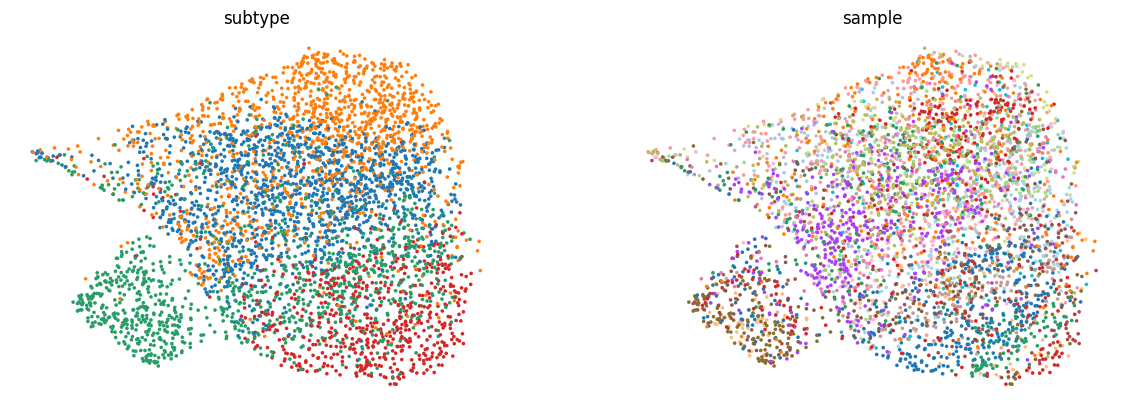

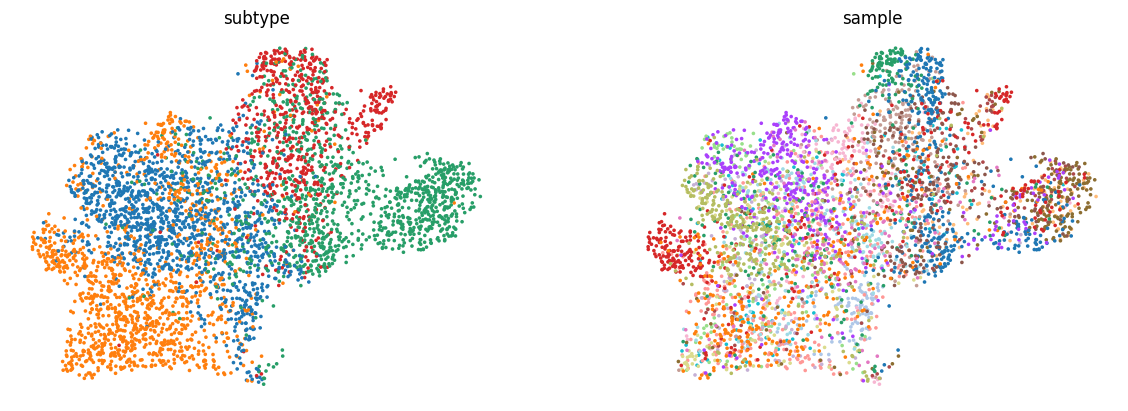

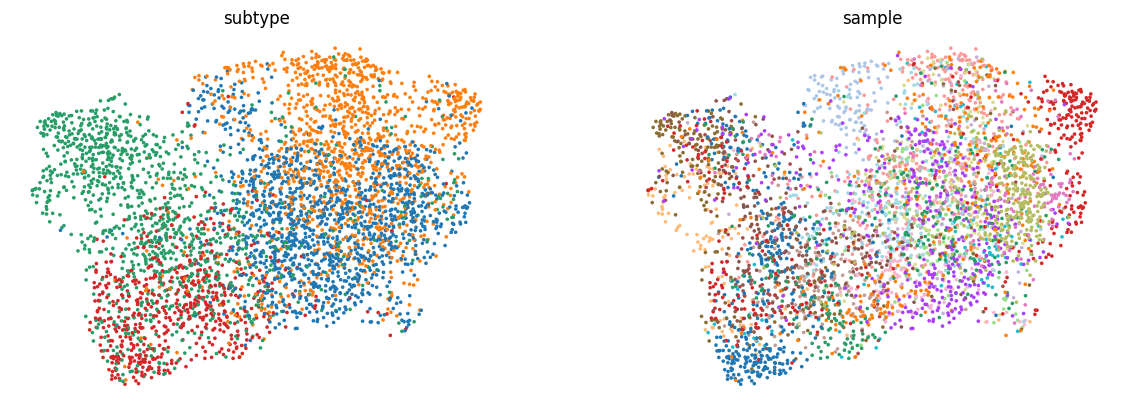

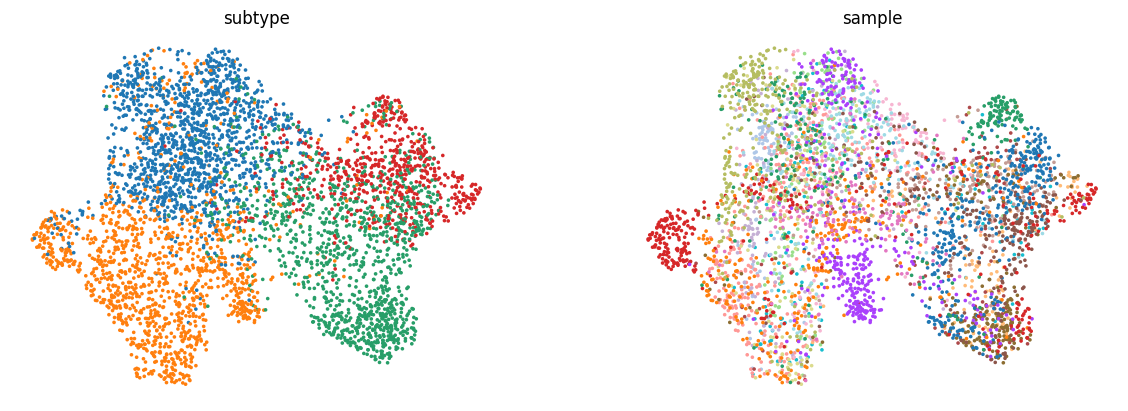

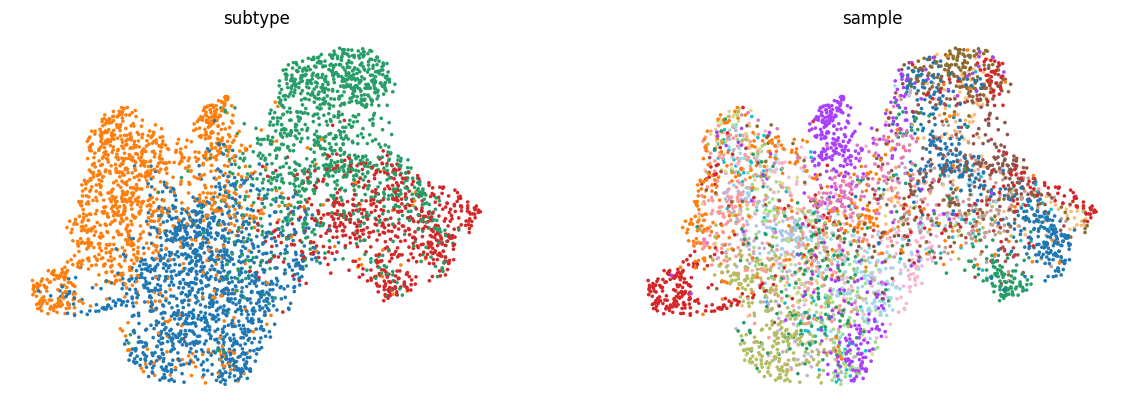

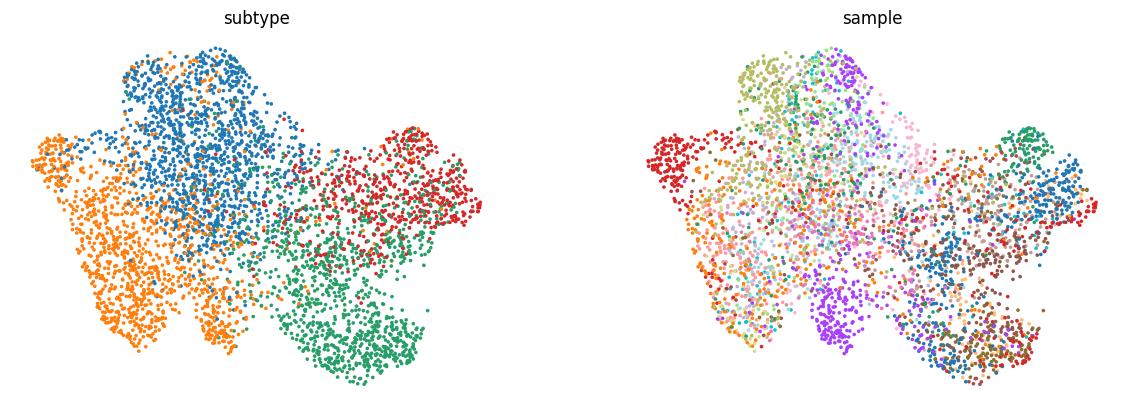

In [5]:
## Generate plots
os.makedirs("./figures/" + dataset, exist_ok=True)
for rep in all_keys:
    sc.pp.neighbors(adata, use_rep=rep)
    sc.tl.umap(adata)
    fig = sc.pl.umap(adata, 
            color=["subtype", "sample"], 
            frameon=False, 
            palette=sc.pl.palettes.default_20,
            legend_loc=None,
            return_fig=True)
    fig.savefig(f"figures/{dataset}/{rep}_umap.png", dpi=300, bbox_inches="tight")

In [48]:
# results may vary slightly given differnet seeds
bio_conservation = BioConservation(nmi_ari_cluster_labels_kmeans=False, nmi_ari_cluster_labels_leiden=True)
batch_correction = BatchCorrection(pcr_comparison=False)

bm = Benchmarker(
    adata,
    batch_key="sample",
    label_key="subtype",
    embedding_obsm_keys=all_keys,
    n_jobs=6,
    bio_conservation_metrics = bio_conservation,
    batch_correction_metrics=batch_correction,
)
bm.benchmark()

/local/home/rvander/miniconda3/envs/cancerfoundation2/lib/python3.9/site-packages/scanpy/preprocessing/_pca.py:377: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None
  warn(msg, FutureWarning)
Embeddings:   0%|          | 0/6 [00:00<?, ?it/s]/local/home/rvander/miniconda3/envs/cancerfoundation2/lib/python3.9/site-packages/scib_metrics/_kbet.py:181: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  comp_size = pd.value_counts(labs)
/local/home/rvander/miniconda3/envs/cancerfoundation2/lib/python3.9/site-packages/scib_metrics/_graph_connectivity.py:30: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  tab = pd.value_counts(comps)
Embeddings: 

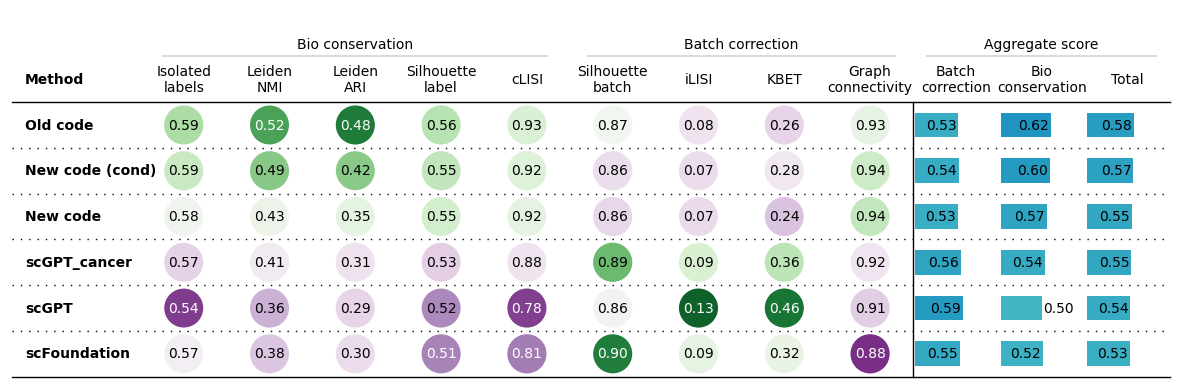

In [49]:
bm.plot_results_table(min_max_scale=False, save_dir="./figures/" + dataset)